# Dev: SSI Distribution Selection and Timescale Comparison

Developer notebook exploring the parts of the SSI workflow that go beyond
[Tutorial 07](07_drought_analysis.ipynb): ranking candidate probability
distributions with `compare_distributions`, and comparing drought detection
across SSI timescales. Not part of the published tutorials (the leading
underscore excludes it from the docs build).

In [1]:
from pathlib import Path

FIG_DIR = Path("figures") / "_dev_drought_distributions"
FIG_DIR.mkdir(parents=True, exist_ok=True)

## Load and prepare data

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from synhydro import load_example_data, SSI, compare_distributions
from synhydro.droughts import get_drought_metrics

SITE_INDEX = 3   # Which site to analyze (0-3)
WINDOW = 12      # Rolling window in months for SSI calculation

Q_daily = load_example_data("usgs_daily_streamflow_cms")
site = Q_daily.columns[SITE_INDEX]
Q_analysis = Q_daily[site].resample("MS").sum()
print(f"Analyzing site: {site}")
print(f"Analysis period: {Q_analysis.index.min().date()} to {Q_analysis.index.max().date()}")

Analyzing site: USGS-01463500
Analysis period: 1945-01-01 to 2025-04-01


## Compare probability distributions

Rank common hydrological distributions by AIC and the Kolmogorov-Smirnov
test to pick the best fit for the SSI transform:

In [3]:
comparison = compare_distributions(
    Q_analysis,
    distributions=["gamma", "lognorm", "pearson3", "weibull_min", "norm"],
    window=WINDOW,
)
print(comparison[["distribution", "aic", "bic", "ks_pvalue", "ks_pass"]].to_string(index=False))

best_dist = comparison.iloc[0]["distribution"]
print(f"\nRecommended distribution: {best_dist}")

distribution          aic          bic  ks_pvalue  ks_pass
       gamma 22614.646710 22629.225554   0.973762     True
     lognorm 22614.988665 22629.567510   0.950000     True
    pearson3 22614.646710 22629.225554   0.973762     True
 weibull_min 22620.723478 22635.302323   0.550554     True
        norm 22644.186059 22653.905289   0.086739     True

Recommended distribution: gamma


## Calculate SSI with the recommended distribution

In [4]:
ssi_calc = SSI(dist=best_dist, timescale=WINDOW, fit_freq="ME")
ssi_values = ssi_calc.fit_transform(Q_analysis)

print(f"Mean: {ssi_values.mean():.3f} (should be ~0)")
print(f"Std:  {ssi_values.std():.3f} (should be ~1)")
print(f"Min:  {ssi_values.min():.3f}")
print(f"Max:  {ssi_values.max():.3f}")

Mean: 0.000 (should be ~0)
Std:  1.001 (should be ~1)
Min:  -2.902
Max:  2.865


## Extract drought events

In [5]:
drought_metrics = get_drought_metrics(ssi_values)
print(f"Total droughts detected: {len(drought_metrics)}")
drought_metrics.nsmallest(5, "severity")

Total droughts detected: 12


,start,end,duration,magnitude,severity,avg_severity,max_severity_date,recovery_period,prior_1m_surplus,prior_3m_surplus,prior_6m_surplus
4,1961-08-01,1970-03-01,104,-132.855574,-2.901521,-1.277457,1966-01-01,51,0.019352,0.220568,0.443260
11,2001-01-01,2003-02-01,26,-26.568170,-2.158026,-1.021853,2002-04-01,11,0.012283,0.012283,0.333967
6,1985-03-01,1986-03-01,13,-15.525892,-1.985090,-1.194299,1985-08-01,8,0.119687,1.042415,4.162442
5,1980-05-01,1983-03-01,35,-33.791837,-1.851443,-0.965481,1981-04-01,24,0.117058,0.302716,2.778459
12,2014-06-01,2018-07-01,50,-37.376577,-1.844639,-0.747532,2017-02-01,18,0.196584,0.196584,0.196584


## Compare SSI timescales

The rolling window length controls which droughts the index resolves:
short windows (3 months) catch seasonal events, long windows (12 months)
emphasize multi-year droughts.

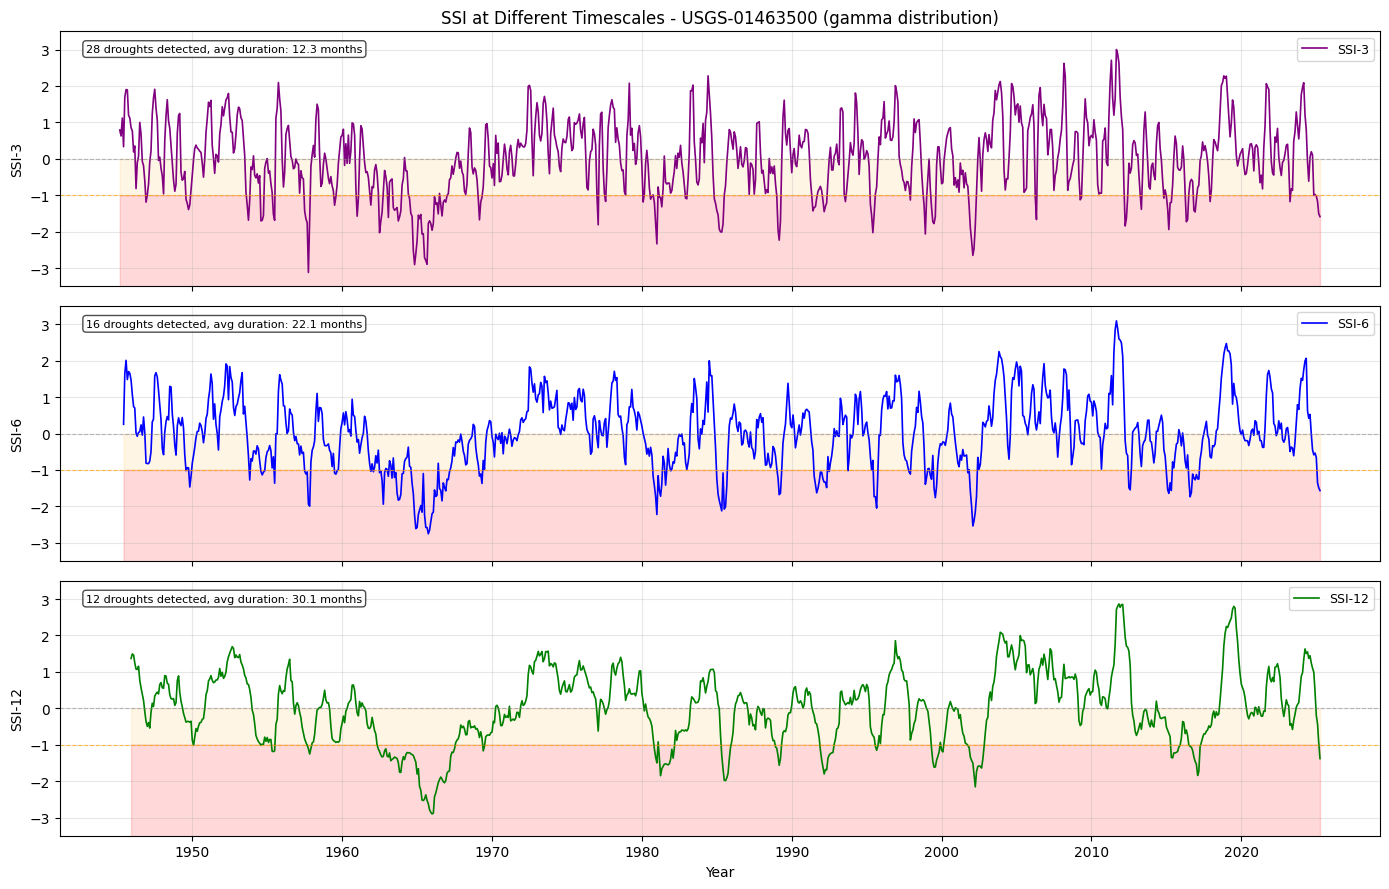

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
windows = [3, 6, 12]
colors_list = ["purple", "blue", "green"]

for ax, window, color in zip(axes, windows, colors_list):
    ssi_temp = SSI(dist=best_dist, timescale=window, fit_freq="ME").fit_transform(Q_analysis)
    droughts_temp = get_drought_metrics(ssi_temp)

    ax.plot(ssi_temp.index, ssi_temp.values, color=color, linewidth=1.2, label=f"SSI-{window}")
    ax.axhline(0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
    ax.axhline(-1, color="orange", linestyle="--", linewidth=0.8, alpha=0.7)
    ax.fill_between(ssi_temp.index, -1, 0, alpha=0.1, color="orange")
    ax.fill_between(ssi_temp.index, -4, -1, alpha=0.15, color="red")
    ax.set_ylabel(f"SSI-{window}")
    ax.set_ylim(-3.5, 3.5)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper right", fontsize=9)

    info_text = f"{len(droughts_temp)} droughts detected"
    if len(droughts_temp) > 0:
        info_text += f", avg duration: {droughts_temp['duration'].mean():.1f} months"
    ax.text(0.02, 0.95, info_text, transform=ax.transAxes, fontsize=8,
            verticalalignment="top", bbox=dict(boxstyle="round", facecolor="white", alpha=0.7))

axes[-1].set_xlabel("Year")
axes[0].set_title(f"SSI at Different Timescales - {site} ({best_dist} distribution)")
fig.tight_layout()
fig.savefig(FIG_DIR / "ssi_timescales.png", dpi=150, bbox_inches="tight")